# PneumoScan -- Chest X-Ray Analysis


## Step 0 -- Download & merge datasets, then build splits
Merges two public datasets into one binary (NORMAL / PNEUMONIA) split:

| Dataset | Images | Format | Size on disk |
|---|---|---|---|
| Kaggle Chest X-Ray Pneumonia (Guangzhou/Mooney) | ~5,856 | JPEG | ~1.7 GB |
| RSNA Pneumonia Detection Challenge | ~26,684 | DICOM → JPEG* | ~1.5 GB after conversion |

*DICOMs are converted to 512×512 JPEG then deleted immediately to stay within Colab disk limits.

Creates **train (80%) / val (10%) / test (10%)** folders using **symlinks** (no data duplication).

In [ ]:
import os, shutil, numpy as np, pandas as pd
from pathlib import Path
from google.colab import files

#Kaggle credentials (I made it this way so everyone can use their api privately)
print("Upload kaggle.json  (kaggle.com → Settings → API → Create New Token)")
uploaded = files.upload()
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!pip install kaggle pydicom pillow -q

#1. Guangzhou
print("\n[1/2] Downloading Guangzhou dataset...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia \
    -p /content/guangzhou --unzip --quiet
print("Guangzhou downloaded ✓")

# Flatten the pre-made train/val/test splits into one index.
# Labels are encoded in folder names (NORMAL / PNEUMONIA).
guangzhou_root = Path("/content/guangzhou/chest_xray")
guangzhou_rows = []
for img_path in guangzhou_root.rglob("*.jpeg"):

    label = img_path.parent.name.upper()          # NORMAL or PNEUMONIA
    if label in ("NORMAL", "PNEUMONIA"):
        guangzhou_rows.append({"path": str(img_path.resolve()),
                                "label": label,
                                "source": "guangzhou"})
df_gz = pd.DataFrame(guangzhou_rows)
print(f"Guangzhou: {len(df_gz)} images | {df_gz['label'].value_counts().to_dict()}")

# 2. RSNA Pneumonia Detection Challenge
print("\n[2/2] Downloading RSNA dataset (DICOMs)...")
!kaggle competitions download -c rsna-pneumonia-detection-challenge \
    -p /content/rsna --quiet
import zipfile, glob
for zf in glob.glob("/content/rsna/*.zip"):
    print(f"  Extracting {Path(zf).name}...")
    with zipfile.ZipFile(zf) as z:
        z.extractall("/content/rsna")
    os.remove(zf)
print("RSNA downloaded ✓")

label_csv = pd.read_csv("/content/rsna/stage_2_train_labels.csv")
label_map  = (label_csv.groupby("patientId")["Target"]
              .max()                        # any box = pneumonia
              .map({1: "PNEUMONIA", 0: "NORMAL"})
              .to_dict())

import pydicom
from PIL import Image
import io

rsna_jpg_dir = Path("/content/rsna/jpegs")
rsna_jpg_dir.mkdir(exist_ok=True)
rsna_dcm_dir = Path("/content/rsna/stage_2_train_images")

dcm_files = sorted(rsna_dcm_dir.glob("*.dcm"))
print(f"Converting {len(dcm_files)} DICOMs → JPEG (512×512)...")

rsna_rows = []
for i, dcm_path in enumerate(dcm_files):
    patient_id = dcm_path.stem
    if patient_id not in label_map:
        dcm_path.unlink()   # no label, skip and free space
        continue
    ds       = pydicom.dcmread(str(dcm_path))
    arr      = ds.pixel_array.astype(np.float32)
    arr      = ((arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255).astype(np.uint8)
    img      = Image.fromarray(arr).convert("RGB").resize((512, 512), Image.LANCZOS)

    jpg_path = rsna_jpg_dir / f"{patient_id}.jpg"
    img.save(str(jpg_path), "JPEG", quality=88)

    rsna_rows.append({"path":   str(jpg_path.resolve()),
                      "label":  label_map[patient_id],
                      "source": "rsna"})

    dcm_path.unlink()    # ← delete DICOM immediately after converting

    if (i + 1) % 2000 == 0:
        print(f"  {i + 1}/{len(dcm_files)} converted...")

# Remove now-empty DICOM folder to reclaim inode space.
shutil.rmtree(str(rsna_dcm_dir), ignore_errors=True)

df_rsna = pd.DataFrame(rsna_rows)
print(f"RSNA: {len(df_rsna)} images | {df_rsna['label'].value_counts().to_dict()}")

# 3. Merge
df = pd.concat([df_gz, df_rsna], ignore_index=True)
print(f"\nMerged: {len(df)} images total")
print(df.groupby(["source", "label"]).size().to_string())

#    4. Stratified 80 / 10 / 10 split
from sklearn.model_selection import train_test_split

train_df, tmp_df = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=42)
val_df,  test_df  = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df["label"], random_state=42)

print(f"\nSplit sizes → train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")

#  5. Build split folders using symlinks
# Keras flow_from_directory follows symlinks transparently.
for split, subset in [("train", train_df), ("val", val_df), ("test", test_df)]:
    for lbl in ["NORMAL", "PNEUMONIA"]:
        os.makedirs(f"/content/splits/{split}/{lbl}", exist_ok=True)
    for idx, row in subset.iterrows():
        src = row["path"]
        ext = Path(src).suffix
        dst = f'/content/splits/{split}/{row["label"]}/{row["source"]}_{idx}{ext}'
        if not os.path.exists(dst):
            os.symlink(src, dst)
    counts = {l: len(os.listdir(f"/content/splits/{split}/{l}")) for l in ["NORMAL", "PNEUMONIA"]}
    print(f"  {split}: {counts}")

print("\nDataset ready (symlinks, no duplication) -- continue to Step 2")

Upload kaggle.json  (kaggle.com → Settings → API → Create New Token)


Saving kaggle.json to kaggle.json
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.9 MB/s eta 0:00:00

[1/2] Downloading Guangzhou dataset...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Guangzhou downloaded ✓
Guangzhou: 17568 images | {'PNEUMONIA': 12819, 'NORMAL': 4749}

[2/2] Downloading RSNA dataset (DICOMs)...
  Extracting rsna-pneumonia-detection-challenge.zip...
RSNA downloaded ✓
Converting 26684 DICOMs → JPEG (512×512)...
  2000/26684 converted...
  4000/26684 converted...
  6000/26684 converted...
  8000/26684 converted...
  10000/26684 converted...
  12000/26684 converted...
  14000/26684 converted...
  16000/26684 converted...
  18000/26684 converted...
  20000/26684 converted...
  22000/26684 converted...
  24000/26684 converted...
  26000/26684 converted...
RSNA: 26684 images | {'NORMAL': 20672, 'PNEUMONIA': 6012}

Merged: 44252 images total
source     label    
guangzhou  NORMAL        4749
           PNEUM

## Step 1 -- Mount Drive *(skip if you ran Step 0)*

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
print("Drive mounted ✓")

Mounted at /content/drive
Drive mounted ✓


## Step 2 -- Install dependencies

In [ ]:
!pip install flask pyngrok pillow opencv-python-headless scikit-learn pydicom -q
print("Dependencies installed ✓")

Dependencies installed ✓


## Step 2.5 -- Load existing model or train from scratch
- **N** -- trains fresh (Step 3 runs)
- **Y -> N** -- uploads model and uses it as-is, jumps to Step 4
- **Y -> Y** -- uploads model and fine-tunes on RSNA + Guangzhou data

In [ ]:
import os, numpy as np, tensorflow as tf, cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image as _PILImage

TRAIN_DIR, VAL_DIR, TEST_DIR = "/content/splits/train", "/content/splits/val", "/content/splits/test"
IMG_SIZE, BATCH = 224, 32
SKIP_TRAINING   = False
model           = None

def clahe_preprocess(img):
    img_u8 = np.clip(img, 0, 255).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    for c in range(3): img_u8[:,:,c] = clahe.apply(img_u8[:,:,c])
    return tf.keras.applications.efficientnet.preprocess_input(img_u8.astype(np.float32))

def _scan_split(split_dir):
    removed = 0
    for label in os.listdir(split_dir):
        label_dir = os.path.join(split_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for fname in os.listdir(label_dir):
            fpath = os.path.join(label_dir, fname)
            try:
                with _PILImage.open(fpath) as _img:
                    _img.load()
            except Exception:
                os.remove(fpath)
                removed += 1
    return removed

print("=" * 50)
print("Load an existing trained model?")
print("  [Y] Upload .keras or .h5 file")
print("  [N] Train from scratch (Step 3)")
print("=" * 50)
choice = input("Choice (Y/N): ").strip().upper()

if choice == "Y":
    from google.colab import files as cf
    uploaded_model = cf.upload()
    model_path = list(uploaded_model.keys())[0]
    model = tf.keras.models.load_model(model_path, compile=False)
    print(f"\nLoaded: {model_path}  {model.input_shape} -> {model.output_shape}")

    retrain = input("\nFine-tune on RSNA + Guangzhou data? (Y/N): ").strip().upper()
    if retrain == "Y":
        print("Scanning for corrupt images (this may take ~1-2 min)...")
        for _sd in [TRAIN_DIR, VAL_DIR]:
            _n = _scan_split(_sd)
            print(f"  {_sd}: removed {_n} unreadable file(s)")
        print("Scan complete ✓")
        #Giving the user the choice between fine-tuning an already existant model
        gen_args = dict(preprocessing_function=clahe_preprocess)
        aug_args = dict(rotation_range=15, width_shift_range=0.1,
                        height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True)
        train_data = ImageDataGenerator(**gen_args, **aug_args).flow_from_directory(
            TRAIN_DIR, target_size=(IMG_SIZE,IMG_SIZE),
            class_mode="categorical", batch_size=BATCH, shuffle=True)
        val_data = ImageDataGenerator(**gen_args).flow_from_directory(
            VAL_DIR, target_size=(IMG_SIZE,IMG_SIZE),
            class_mode="categorical", batch_size=BATCH, shuffle=False)

        cw_arr = compute_class_weight("balanced",
            classes=np.unique(train_data.classes), y=train_data.classes)
        class_weight = dict(enumerate(cw_arr))

        try:
            base = model.get_layer("efficientnetb0")
            base.trainable = True
            for layer in base.layers[:-30]: layer.trainable = False
            print("Unfroze top-30 EfficientNet layers ✓")
        except Exception:
            model.trainable = True

        model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                      loss="categorical_crossentropy", metrics=["accuracy"])
        model.fit(train_data, validation_data=val_data, epochs=10,
                  class_weight=class_weight, callbacks=[
                      tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
                      tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-8),
                  ])
        model.save("pneumonia_finetuned.keras")
        print("Saved: pneumonia_finetuned.keras ✓")
        cf.download("pneumonia_finetuned.keras")
    else:
        print("Using uploaded model as-is ✓")

    SKIP_TRAINING = True
else:
    print("Proceeding to full training in Step 3 ✓")

Load an existing trained model?
  [Y] Upload .keras or .h5 file
  [N] Train from scratch (Step 3)
Choice (Y/N): Y


Saving pneumonia_finetuned.keras to pneumonia_finetuned (1).keras

Loaded: pneumonia_finetuned (1).keras  (None, 224, 224, 3) -> (None, 2)

Fine-tune on RSNA + Guangzhou data? (Y/N): N
Using uploaded model as-is ✓


## Step 3 -- Train EfficientNetB0 with SE attention + Focal Loss
> Auto-skipped if you loaded a model in Step 2.5.

**Key upgrades from v3:**
- **SE (Squeeze-and-Excitation) attention** -- after GlobalAveragePooling, a small bottleneck network learns which of the 1280 EfficientNet channels matter most for the classification decision. Adds ~50K params, ~2-3% accuracy gain per published research.
- **Focal Loss** (gamma=2, alpha=0.25) -- downweights easy correctly-classified examples so training focuses on hard/borderline cases. Essential for NIH data where NORMAL outnumbers PNEUMONIA.
- **CLAHE preprocessing** -- per-channel adaptive histogram equalization applied before EfficientNet normalization. Improves edge/texture visibility in low-contrast X-rays.
- **Cosine Decay LR** -- smooth annealing from 1e-3 to near-zero over all epochs. More stable than plateau-based reduction.
- **Grad-CAM model saved at training time** -- eliminates the tf_keras conversion step from v3 entirely.

In [ ]:
if SKIP_TRAINING:
    print("Training skipped -- model loaded from Step 2.5 ✓")
else:
    import os, cv2, numpy as np, tensorflow as tf
    from tensorflow.keras import layers, models, Input
    from tensorflow.keras.applications import EfficientNetB0
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    from sklearn.utils.class_weight import compute_class_weight

    TRAIN_DIR = "/content/splits/train"
    VAL_DIR   = "/content/splits/val"
    IMG_SIZE, BATCH, EPOCHS = 224, 32, 25

    for d in [TRAIN_DIR, VAL_DIR]:
        if not os.path.isdir(d):
            raise FileNotFoundError(f"Not found: {d} -- run Step 0 first")
    # Applies per-channel adaptive histogram equalization before EfficientNet
    #Boosts contrast in flat regions of chest X-rays.
    def clahe_preprocess(img):
        img_u8 = np.clip(img, 0, 255).astype(np.uint8)
        clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        for c in range(3): img_u8[:,:,c] = clahe.apply(img_u8[:,:,c])
        return tf.keras.applications.efficientnet.preprocess_input(img_u8.astype(np.float32))

    gen_args = dict(preprocessing_function=clahe_preprocess)
    aug_args = dict(rotation_range=15, width_shift_range=0.1,
                    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True)

    train_data = ImageDataGenerator(**gen_args, **aug_args).flow_from_directory(
        TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
        class_mode="categorical", batch_size=BATCH, shuffle=True)
    val_data   = ImageDataGenerator(**gen_args).flow_from_directory(
        VAL_DIR,   target_size=(IMG_SIZE, IMG_SIZE),
        class_mode="categorical", batch_size=BATCH, shuffle=False)

    cw_arr = compute_class_weight("balanced",
        classes=np.unique(train_data.classes), y=train_data.classes)
    class_weight = dict(enumerate(cw_arr))
    print("Class weights:", class_weight)
    print("Class indices:", train_data.class_indices)
    # Standard focal loss from RetinaNet (Lin et al., 2017).
    # gamma=2 concentrates training on hard examples.
    # alpha=0.25 slightly upweights the minority (Pneumonia) class.
    def focal_loss(gamma=2.0, alpha=0.25):
        def loss_fn(y_true, y_pred):
            eps    = tf.keras.backend.epsilon()
            y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
            ce     = -y_true * tf.math.log(y_pred)
            weight = alpha * tf.pow(1.0 - y_pred, gamma)
            return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=-1))
        return loss_fn

    #Model: EfficientNetB0 + SE attention head
    print("\n-- Phase 1: Training head (EfficientNet frozen) --")

    base = EfficientNetB0(weights="imagenet", include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)              # (None, 7, 7, 1280)
    x = layers.GlobalAveragePooling2D()(x)        # (None, 1280)

    # SE block: learns channel importance weights
    # 1280 -> 80 (squeeze) -> 1280 (excite) -> scale original features
    se = layers.Dense(80,   activation="relu",    use_bias=False, name="se_squeeze")(x)
    se = layers.Dense(1280, activation="sigmoid", use_bias=False, name="se_excite")(se)
    x  = layers.Multiply(name="se_scale")([x, se])

    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(2, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    steps_per_epoch = len(train_data)
    lr_sched = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3,
        decay_steps=steps_per_epoch * EPOCHS,
        alpha=1e-7
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr_sched),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=["accuracy"]
    )
    model.summary()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    ]

    model.fit(train_data, validation_data=val_data,
              epochs=EPOCHS, class_weight=class_weight, callbacks=callbacks)

    # Phase 2: Fine-tune top-30 EfficientNet layers
    print("\n-- Phase 2: Fine-tuning top-30 EfficientNet layers --")
    base.trainable = True
    for layer in base.layers[:-30]: layer.trainable = False

    lr_ft = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-5,
        decay_steps=steps_per_epoch * 10,
        alpha=1e-8
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr_ft),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=["accuracy"]
    )
    model.fit(train_data, validation_data=val_data,
              epochs=10, class_weight=class_weight, callbacks=callbacks)

    # Save main model
    model.save("pneumonia_model.keras")
    print("\nSaved: pneumonia_model.keras ✓")

    # Save Grad-CAM model at training time
    # without the nested model / tf_keras workaround needed in v3.
    grad_cam_model = tf.keras.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer("efficientnetb0").output, model.output]
    )
    grad_cam_model.save("pneumonia_gradcam_model.keras")
    print("Saved: pneumonia_gradcam_model.keras ✓")

    from google.colab import files as cf
    cf.download("pneumonia_model.keras")
    cf.download("pneumonia_gradcam_model.keras")

    import shutil
    for fname in ["pneumonia_model.keras", "pneumonia_gradcam_model.keras"]:
        try:
            shutil.copy(fname, f"/content/drive/MyDrive/{fname}")
            print(f"Drive backup: {fname} ✓")
        except Exception as e:
            print(f"Drive backup skipped ({fname}): {e}")

Training skipped -- model loaded from Step 2.5 ✓


## Step 3.5 -- Evaluate on test set
AUC-ROC, confusion matrix, and per-class precision/recall/F1 on the held-out 10% test split.
This was missing from v3 entirely -- taken from the Kaggle reference notebook's evaluation approach.

Scanning test split for corrupt images...
  Removed 0 unreadable file(s) ✓
Found 3835 images belonging to 2 classes.
120/120 ━━━━━━━━━━━━━━━━━━━━ 41s 273ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.88      0.88      0.88      2392
   PNEUMONIA       0.80      0.81      0.80      1443

    accuracy                           0.85      3835
   macro avg       0.84      0.84      0.84      3835
weighted avg       0.85      0.85      0.85      3835

AUC-ROC: 0.9254


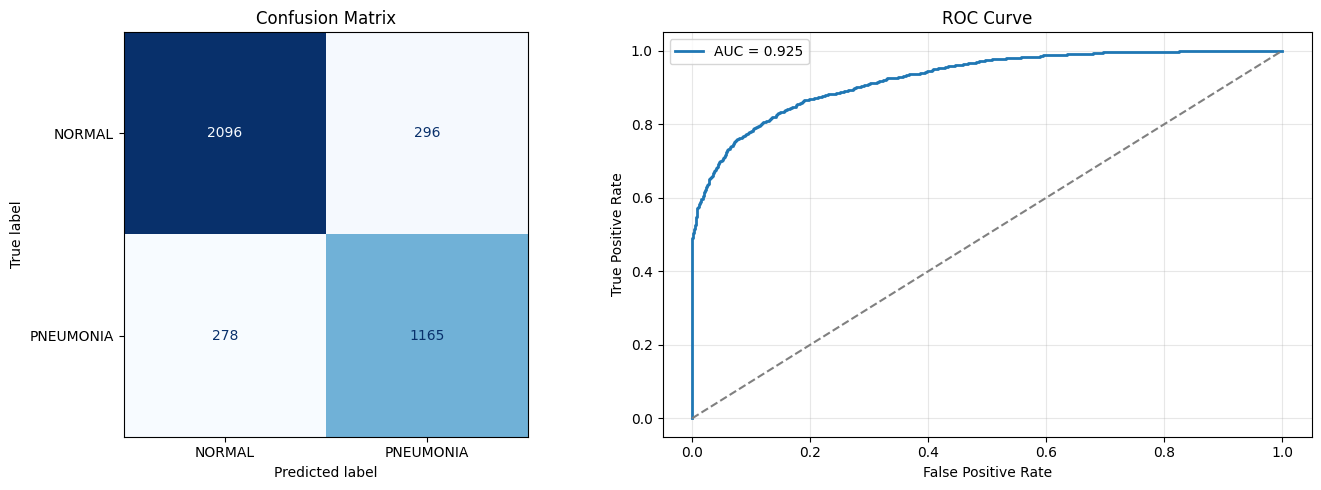


Saved: evaluation.png ✓


In [ ]:
import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf, cv2
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image as _PILImage

TEST_DIR = "/content/splits/test"
IMG_SIZE = 224

def _scan_split(split_dir):
    removed = 0
    for label in os.listdir(split_dir):
        label_dir = os.path.join(split_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for fname in os.listdir(label_dir):
            fpath = os.path.join(label_dir, fname)
            try:
                with _PILImage.open(fpath) as _img:
                    _img.load()
            except Exception:
                os.remove(fpath)
                removed += 1
    return removed

print("Scanning test split for corrupt images...")
_n = _scan_split(TEST_DIR)
print(f"  Removed {_n} unreadable file(s) ✓")

def clahe_preprocess(img):
    img_u8 = np.clip(img, 0, 255).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    for c in range(3): img_u8[:,:,c] = clahe.apply(img_u8[:,:,c])
    return tf.keras.applications.efficientnet.preprocess_input(img_u8.astype(np.float32))

test_gen  = ImageDataGenerator(preprocessing_function=clahe_preprocess)
test_data = test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical", batch_size=32, shuffle=False)

# Predict
preds_prob  = model.predict(test_data, verbose=1)
y_pred      = np.argmax(preds_prob, axis=1)
y_true      = test_data.classes
class_names = list(test_data.class_indices.keys())

#  Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

auc = roc_auc_score(y_true, preds_prob[:, 1])
print(f"AUC-ROC: {auc:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_true, preds_prob[:, 1])
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0,1],[0,1],"--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: evaluation.png ✓")